In [1]:

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer , PorterStemmer
from nltk.corpus import wordnet



c:\Users\a7axe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.sparse import csr_matrix, issparse


In [2]:

nltk.download("wordnet")
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\a7axe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\a7axe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\a7axe\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [6]:
import requests

url = "https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv"
r = requests.get(url)

with open("bbc_text_cls.csv", "wb") as f:
    f.write(r.content)

In [7]:
df = pd.read_csv("bbc_text_cls.csv")

In [8]:
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [9]:
inputs = df["text"]
labels = df["labels"]

In [ ]:
print(labels)

0       business
1       business
2       business
3       business
4       business
          ...   
2220        tech
2221        tech
2222        tech
2223        tech
2224        tech
Name: labels, Length: 2225, dtype: object


<Axes: >

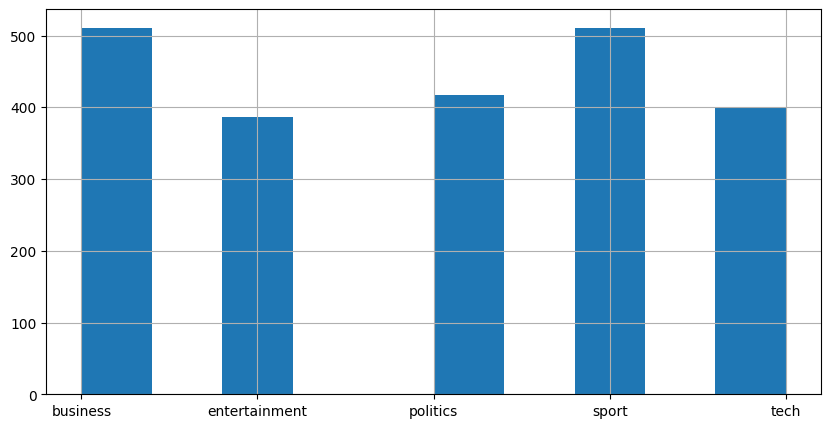

In [11]:
labels.hist(figsize=(10,5))

In [18]:
input_train , input_test , Ytrain , yTest = train_test_split(inputs , labels , random_state=59)

In [19]:
vectorizer = CountVectorizer()

In [20]:
xTrain = vectorizer.fit_transform(input_train)
xTest = vectorizer.transform(input_test)


In [21]:
xTrain

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 336458 stored elements and shape (1668, 26101)>

In [22]:
(xTrain!=0).sum()

336458

In [23]:
(xTrain!=0).sum() / np.prod(xTrain.shape)

0.007728187780414342

In [24]:
model = MultinomialNB()
model.fit(xTrain ,Ytrain)
print("train score ", model.score(xTrain,Ytrain))
print("test score ", model.score(xTest ,yTest))


train score  0.9928057553956835
test score  0.9820466786355476


In [25]:
vectorizer = CountVectorizer(stop_words="english")
xTrain = vectorizer.fit_transform(input_train)
xTest = vectorizer.transform(input_test)
model = MultinomialNB()
model.fit(xTrain ,Ytrain)
print("train score ", model.score(xTrain,Ytrain))
print("test score ", model.score(xTest ,yTest))


train score  0.9946043165467626
test score  0.9802513464991023


In [26]:

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


In [27]:
class lemmaTokenizer:
    def __init__(self):
        self.wnl = WordNetLemmatizer()
    def __call__(self, doc):
        tokens = word_tokenize(doc)
        word_and_tags = nltk.pos_tag(tokens)
        return [self.wnl.lemmatize(word , pos=get_wordnet_pos(tag)) \
                 for word ,tag in word_and_tags
                ]

In [ ]:
vectorizer = CountVectorizer(tokenizer=lemmaTokenizer())
xTrain = vectorizer.fit_transform(input_train)
xTest = vectorizer.transform(input_test)

model = MultinomialNB()
model.fit(xTrain ,Ytrain)
print("train score ", model.score(xTrain,Ytrain))
print("test score ", model.score(xTest ,yTest))


c:\Users\a7axe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score 0.9940047961630696
test score 0.9766606822262118


In [31]:
class stemTokenizer:
    def __init__(self):
        self.porter = PorterStemmer()
    def __call__(self, doc):
        tokens = word_tokenize(doc)
        return [self.porter.stem(t) for t in tokens]

In [32]:
vectorizer = CountVectorizer(tokenizer=stemTokenizer())
xTrain = vectorizer.fit_transform(input_train)
xTest = vectorizer.transform(input_test)

model = MultinomialNB()
model.fit(xTrain ,Ytrain)
print("train score ", model.score(xTrain,Ytrain))
print("test score ", model.score(xTest ,yTest))


c:\Users\a7axe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score  0.9910071942446043
test score  0.9784560143626571


In [33]:
def simple_tokenizer(s):
    return s.split()


In [35]:
vectorizer = CountVectorizer(tokenizer=simple_tokenizer)
xTrain = vectorizer.fit_transform(input_train)
xTest = vectorizer.transform(input_test)

model = MultinomialNB()
model.fit(xTrain ,Ytrain)
print("train score ", model.score(xTrain,Ytrain))
print("test score ", model.score(xTest ,yTest))


c:\Users\a7axe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score  0.9964028776978417
test score  0.9712746858168761
